In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import json
from pathlib import Path
from os import listdir
from os.path import isfile, join
from cellpose import plot, utils, io
from microfilm.microplot import microshow
import skimage.measure as sm
import pandas as pd
from nd2 import ND2File 
import phenotyping as ph
#import segmentation_pipeline_CP4_updated as sg
import image_functions as imf

# For better visualization
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)

In [2]:
# Image Visualization Functions

def visualize_image(data, title="Image", channels=None, cmap='gray', figsize=(15, 5), percentile=[0,100]):
    """
    Visualize multi-channel or single-channel image.
    
    Parameters:
    -----------
    data : np.ndarray
        Image data (CYX or YX)
    title : str
        Main title
    channels : list
        List of channel names (optional)
    cmap : str or list
        Colormap(s) to use
    """
    
    if data.ndim == 3:
        # Multi-channel image
        n_channels = data.shape[0]
        fig, axes = plt.subplots(2, n_channels, figsize=figsize)
        
        if n_channels == 1:
            axes = [axes]
        
        for i in range(n_channels):
            p_min=np.percentile(data[i], percentile[0])
            p_max=np.percentile(data[i], percentile[1])
            
            im = axes[0, i].imshow(data[i], cmap=cmap if isinstance(cmap, str) else cmap[i], vmin=p_min, vmax=p_max)
            channel_name = channels[i] if channels and i < len(channels) else f"Channel {i}"
            axes[0, i].set_title(channel_name)
            axes[0, i].axis('off')
            plt.colorbar(im, ax=axes[0, i], fraction=0.04)

            axes[1, i].hist(data[i].ravel(), bins=int(p_max-p_min), range=(p_min, p_max))
        
        fig.suptitle(title, fontsize=16)
        plt.tight_layout()
    else:
        # Single channel
        fig, ax = plt.subplots(1, 1, figsize=(8, 8))
        im = ax.imshow(data, cmap=cmap, vmin=np.percentile(data, percentile[0]), vmax=np.percentile(data, percentile[1]))
        ax.set_title(title)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.04)
        plt.tight_layout()
    
    plt.show()


def visualize_segmentation(image, NUCLEUS_CHANNEL, CELL_CHANNEL, masks_nuc, masks_cells, figsize=(20, 5)):
    """
    Visualize original image with segmentation masks overlaid.
    
    Parameters:
    -----------
    image : np.ndarray
        Original image (CYX or YX)
    masks_nuc : np.ndarray
        Nuclei masks
    masks_cells : np.ndarray
        Cell masks
    channel : int
        Which channel to display (if multi-channel)
    """
    cell_channel = image[CELL_CHANNEL]
    nuc_channel = image[NUCLEUS_CHANNEL]
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    
    # Original image
    axes[0].imshow(nuc_channel + cell_channel)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Nuclei masks
    np.random.seed(42)  # For reproducibility
    colors_nuc = np.random.rand(masks_nuc.max() + 1, 3)
    colors_nuc[0] = [0, 0, 0]  # Background is black
    axes[1].imshow(colors_nuc[masks_nuc], alpha=0.8)
    axes[1].imshow(nuc_channel, cmap='gray', alpha=0.6)
    axes[1].set_title(f'Nuclei Masks ({masks_nuc.max()} nuclei)')
    axes[1].axis('off')
    
    # Cell masks
    np.random.seed(42)  # For reproducibility
    colors_cells = np.random.rand(masks_cells.max() + 1, 3)
    colors_cells[0] = [0, 0, 0]  # Background is black
    axes[2].imshow(colors_cells[masks_cells], alpha=0.8)
    axes[2].imshow(cell_channel, cmap='gray', alpha=0.6)
    axes[2].set_title(f'Cell Masks ({masks_cells.max()} cells)')
    axes[2].axis('off')
    
    # Overlay
    axes[3].imshow(colors_nuc[masks_nuc], alpha=1)
    axes[3].imshow(colors_cells[masks_cells], alpha=0.6)
    axes[3].set_title('Overlay')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Segmentation Summary:")
    print(f"  Total nuclei detected: {masks_nuc.max()}")
    print(f"  Total cells detected: {masks_cells.max()}")

In [3]:
# Set directories for images and masks
INPUT_DIR = "/mnt/isilon/shalemlab/Personal/Greg/dCas9_Optimization/20250331_NtermNLS_Timecourse/Image_Analysis/MaxIPs"
#INPUT_DIR = "/mnt/isilon/shalemlab/Data/Greg/ShalemLab_Microscope/20250422_dCas9_NtermNLSs/20250422_153817_830"
METADATA_DIR = "/mnt/isilon/shalemlab/Personal/Greg/dCas9_Optimization/20250331_NtermNLS_Timecourse/Image_Analysis/Metadata"

MASK_DIR = "/mnt/isilon/shalemlab/Personal/Greg/dCas9_Optimization/20250331_NtermNLS_Timecourse/Image_Analysis/Segmented_CP4_updated2"

In [4]:
# Load image and masks (use same as in segmentation_test)
INPUT_FORMAT = "ome-tiff"  # Options: "ome-tiff", "tiff", "nd2"
WELL = 1
TILE = 1

data, metadata, filename = imf.import_image_by_well_and_tile(
    WELL, TILE, INPUT_DIR,
    input_format=INPUT_FORMAT,
    return_metadata=True,
    metadata_dir=METADATA_DIR
)

data = imf.norm_to_zero(data)


Loaded: Well01_Point01_0001_ChannelBrightfield_CF,488_CF,AF555_CF,AF647_CF,Cy7_CF,AF405CF_Seq0001_max_projection
Shape: (6, 2304, 2304)
Data type: uint16
Channel[0] value range: [445, 11554]
Channel[1] value range: [117, 22141]
Channel[2] value range: [157, 65535]
Channel[3] value range: [237, 9579]
Channel[4] value range: [153, 22465]
Channel[5] value range: [119, 1110]

Metadata:
  Stage position: [{'x': 45601.3, 'y': -30423.100000000002, 'z': 2927.18}]
  Pixel size: {'x': 0.1663971055106, 'y': 0.1663971055106, 'z': 0.6}
  Channels: ['Brightfield_CF', '488_CF', 'AF555_CF', 'AF647_CF', 'Cy7_CF', 'AF405CF']

Normed_to_zero '[[[  53   57   83 ... 3051 2762 2740]
  [  42   59  132 ... 3023 2839 2690]
  [  85  103  140 ... 3075 2813 2739]
  ...
  [3649 3292 3198 ... 2743 2601 2977]
  [3230 3158 3138 ... 2722 2813 2850]
  [3255 3261 3052 ... 2888 2814 2885]]

 [[  38   69   37 ...   45   45   33]
  [  33   26   35 ...   36   59   43]
  [  60   65   52 ...   58   82   57]
  ...
  [  63   6

In [13]:
# Load image and masks (use same as in segmentation_test)
INPUT_FORMAT = "ome-tiff"  # Options: "ome-tiff", "tiff", "nd2"
WELL = 1
TILE = 1

data, metadata, filename = imf.import_image_by_well_and_tile(
    WELL, TILE, INPUT_DIR,
    input_format=INPUT_FORMAT,
    return_metadata=True,
    metadata_dir=METADATA_DIR
)

nucs, cells = ph.load_masks(WELL, TILE, MASK_DIR, use_cleaned=True)
data = imf.norm_to_zero(data)


Loaded: Well01_Point01_0001_ChannelBrightfield_CF,488_CF,AF555_CF,AF647_CF,Cy7_CF,AF405CF_Seq0001_max_projection
Shape: (6, 2304, 2304)
Data type: uint16
Value range: [0, 11109]
Value range: [0, 22024]
Value range: [0, 65378]
Value range: [0, 9342]
Value range: [0, 22312]
Value range: [0, 991]

Metadata:
  Stage position: [{'x': 45601.3, 'y': -30423.100000000002, 'z': 2927.18}]
  Pixel size: {'x': 0.1663971055106, 'y': 0.1663971055106, 'z': 0.6}
  Channels: ['Brightfield_CF', '488_CF', 'AF555_CF', 'AF647_CF', 'Cy7_CF', 'AF405CF']


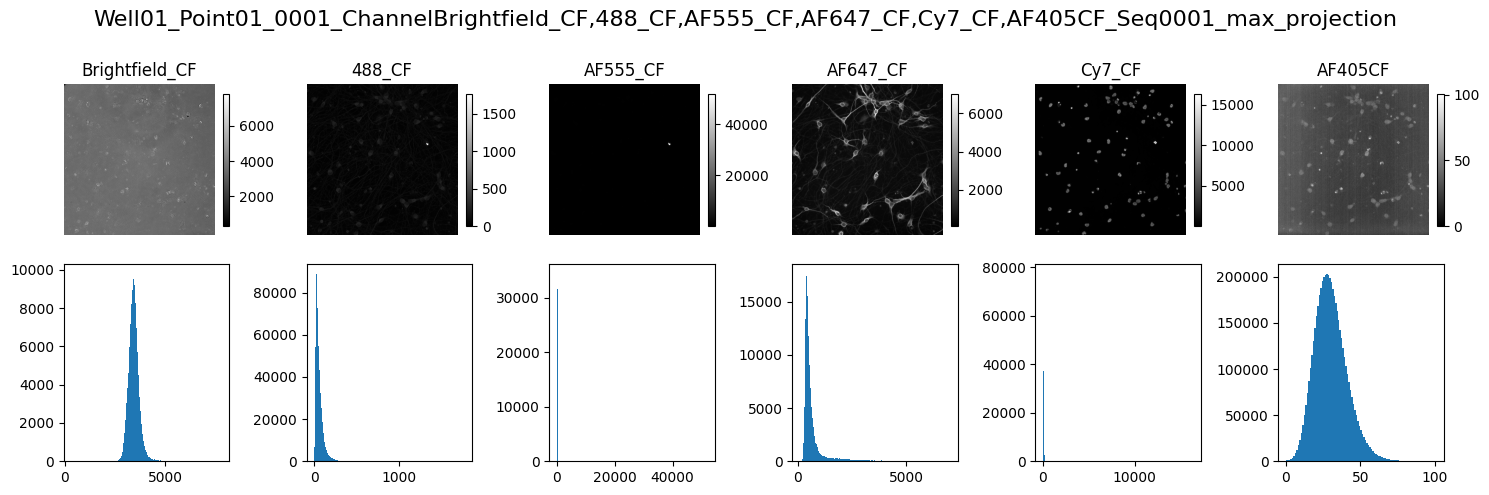

In [7]:
# Get channel names from metadata if available
channel_names = metadata.get('channels', None) if metadata else None

# Visualize all channels
visualize_image(subtract_background(data), title=f"{filename}", channels=channel_names, percentile=[0,99.99])

In [6]:
# Load image and masks (use same as in segmentation_test)
INPUT_FORMAT = "ome-tiff"  # Options: "ome-tiff", "tiff", "nd2"

WELL = 17
TILE = 1

data2, metadata2, filename2 = imf.import_image_by_well_and_tile(
    WELL, TILE, INPUT_DIR,
    input_format=INPUT_FORMAT,
    return_metadata=True,
    metadata_dir=METADATA_DIR
)

nucs2, cells2 = ph.load_masks(WELL, TILE, MASK_DIR, use_cleaned=True)


Loaded: Well17_Point17_0001_ChannelBrightfield_CF,488_CF,AF555_CF,AF647_CF,Cy7_CF,AF405CF_Seq0071_max_projection
Shape: (6, 2304, 2304)
Data type: uint16
Value range: [479, 14915]
Value range: [117, 19674]
Value range: [159, 2209]
Value range: [221, 17302]
Value range: [158, 22141]
Value range: [103, 1102]

Metadata:
  Stage position: [{'x': -31642.5, 'y': 8094.6, 'z': 2959.2400000000002}]
  Pixel size: {'x': 0.1663971055106, 'y': 0.1663971055106, 'z': 0.6}
  Channels: ['Brightfield_CF', '488_CF', 'AF555_CF', 'AF647_CF', 'Cy7_CF', 'AF405CF']


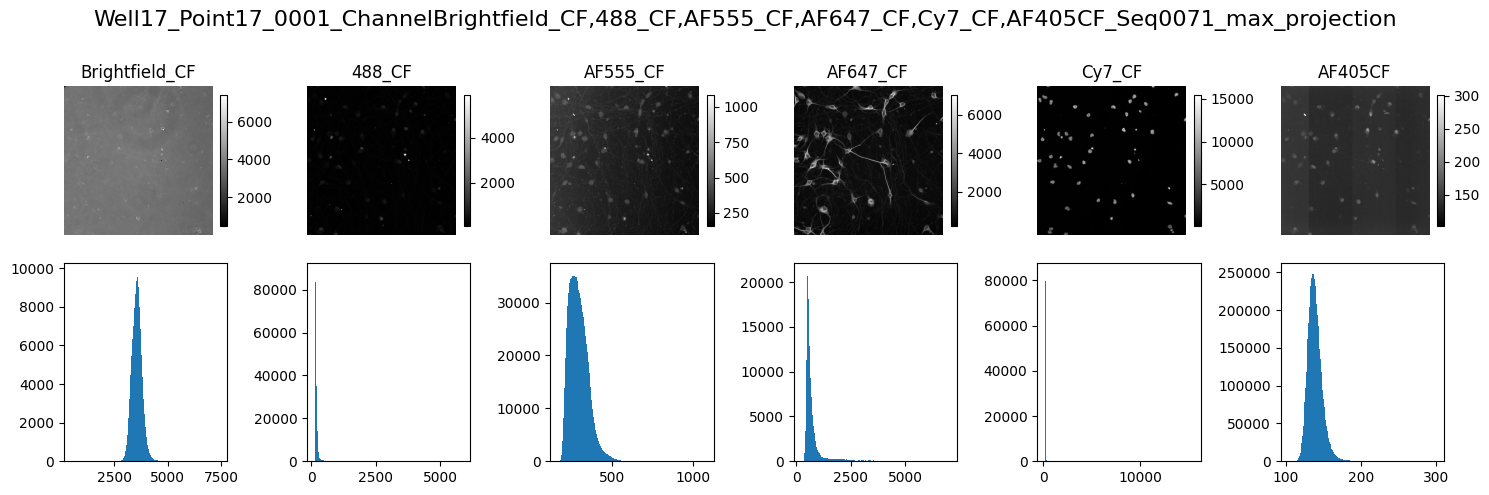

In [7]:
# Get channel names from metadata if available
channel_names2 = metadata2.get('channels', None) if metadata2 else None

# Visualize all channels
visualize_image(data2, title=f"{filename2}", channels=channel_names2, percentile=[0,99.99])

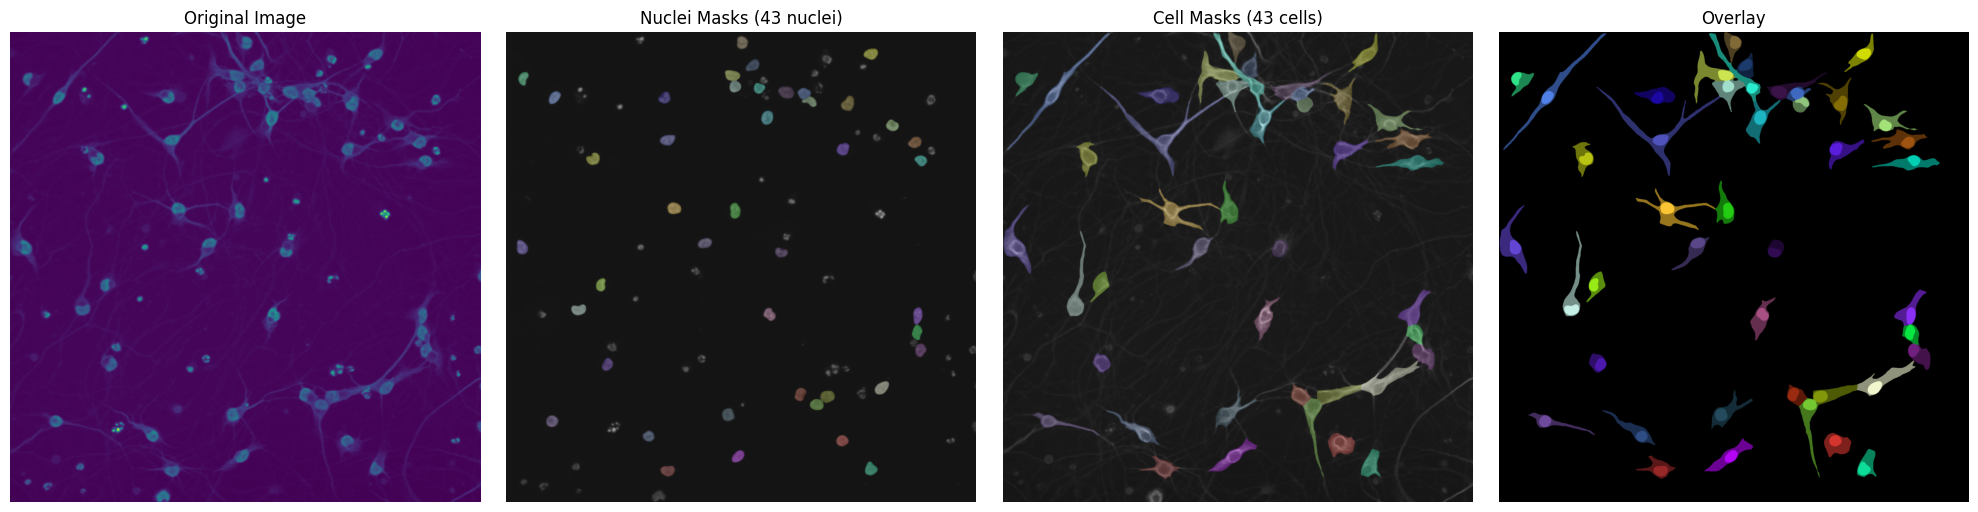

Segmentation Summary:
  Total nuclei detected: 43
  Total cells detected: 43


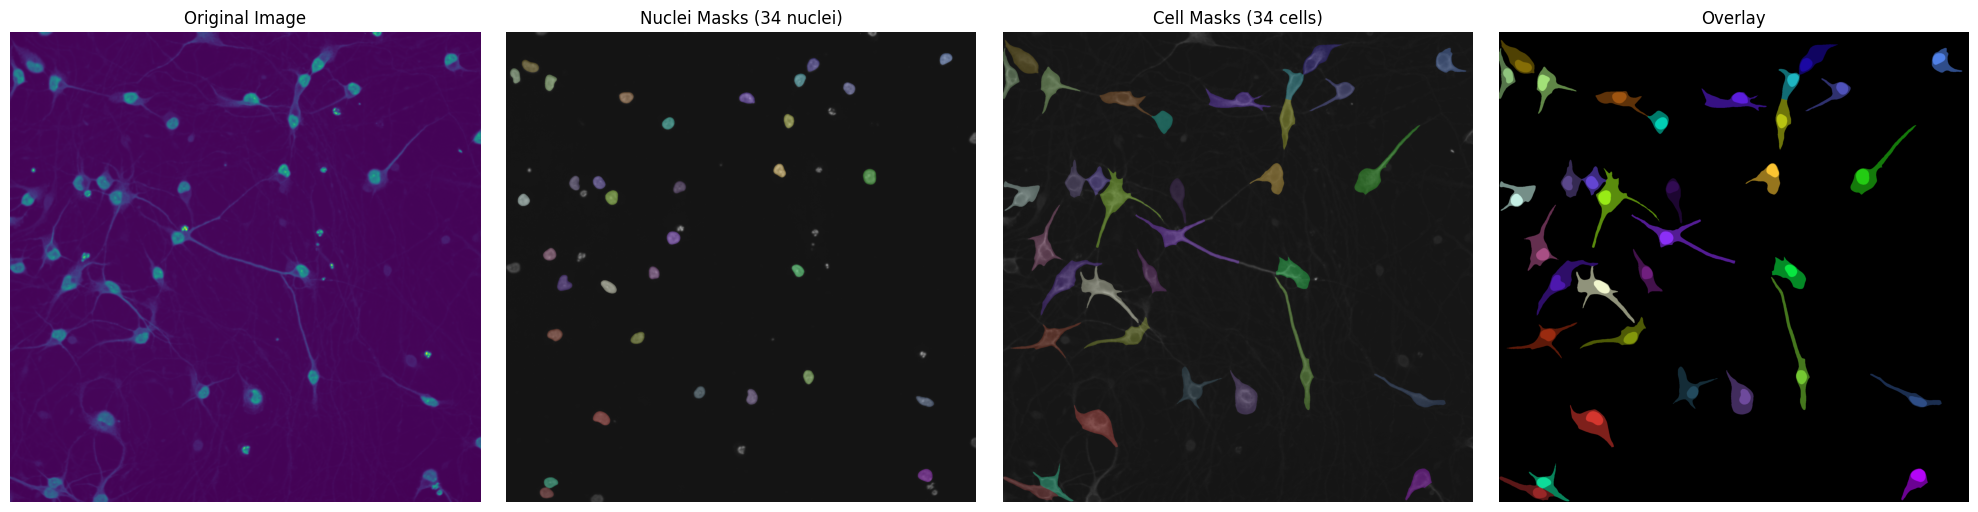

Segmentation Summary:
  Total nuclei detected: 34
  Total cells detected: 34


In [8]:
# Confirm mask files match masks from segmentation_test notebook
NUCLEUS_CHANNEL = 4
CELL_CHANNEL = 3

visualize_segmentation(data, NUCLEUS_CHANNEL, CELL_CHANNEL, nucs, cells)

visualize_segmentation(data2, NUCLEUS_CHANNEL, CELL_CHANNEL, nucs2, cells2)

In [59]:
# Convert masks to outlines with cellpose.utils
outlines_nucs = utils.outlines_list(nucs)
outlines_cells = utils.outlines_list(cells)

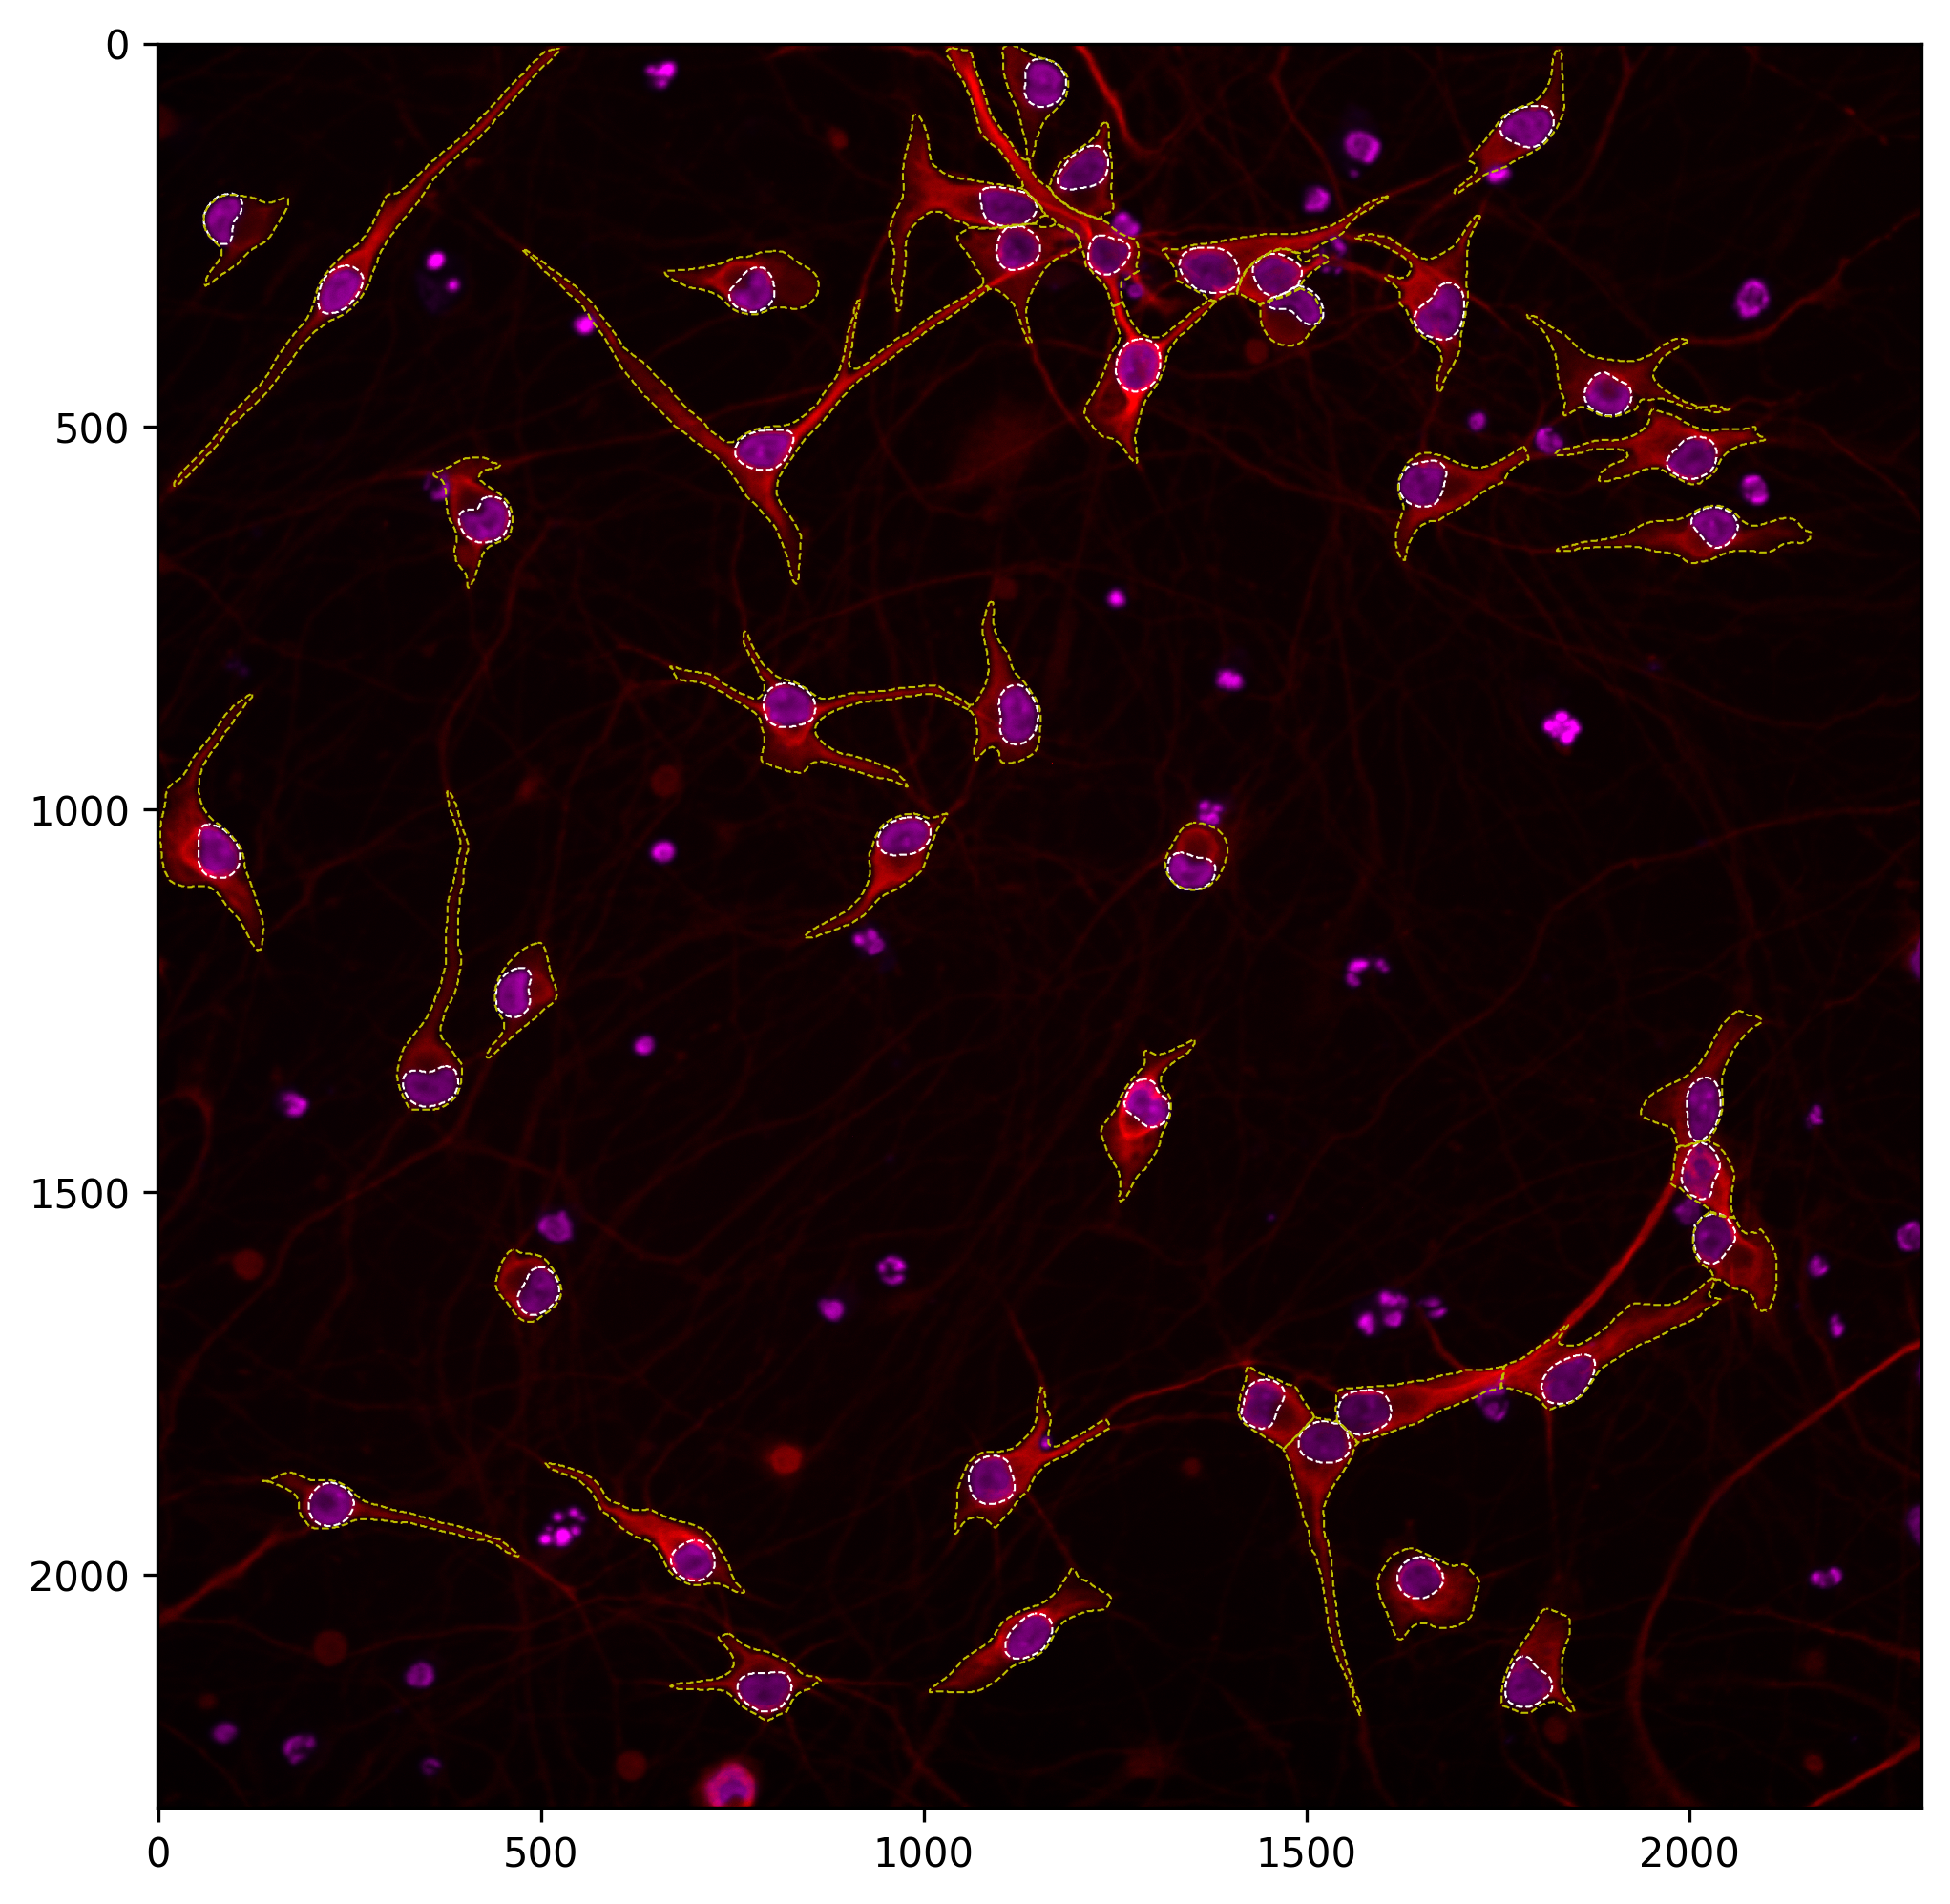

In [60]:
# Plot image with masks as outlines
CHANNELS = [3,4]
colors = ["red", "magenta"]
_, h, w = data.shape
img = np.zeros([len(CHANNELS), h, w])
img[0, :, :] = np.clip((data[3] / 7000), 0, 1)
img[1, :, :] = np.clip((data[4] / 15000), 0, 1)
#img[:, :, 2] = np.clip((data[4] / 15000), 0, 1)

fig, axes = plt.subplots(figsize=(8, 8), dpi=300, frameon=True)
microshow(images=img, cmaps=colors, ax=axes)
for o in outlines_nucs:
    plt.plot(o[:,0], o[:,1], color='w', lw=0.5, ls="dashed")
for o in outlines_cells:
    plt.plot(o[:,0], o[:,1], color='y', lw=0.5, ls="dashed")
#axes.set_xlim(750, 1250) #Use for cropping
#axes.set_ylim(700, 1200) #Use for cropping
plt.axis('on')
#plt.savefig('without_masks.tiff', bbox_inches='tight', pad_inches=0)
plt.show()